# DS3-2 EDA CONTINUED "Median Prices of Existing Single Family Homes" dataset from the California Association of Realtors.

### Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

from pathlib import Path

from scipy import stats
from statsmodels.tsa.stattools import adfuller

In [5]:
# Enforce copy-on-write behavior for pandas DataFrames
pd.options.mode.copy_on_write = True

# Folder Organization
Be sure to download the data from the google drive and place it in the data folder.

In [6]:
# Read in the data file
parent_dir = Path.cwd().parent
data_dir = parent_dir / "data"

csv_path = data_dir / "MedianPricesofExistingDetachedHomesHistoricalData - Median Price.csv"
db_path = data_dir / "housing_data.db"

# If SQlite DB not exist yet, create it from CSV
if not db_path.exists():
    print("SQLite DB not found, creating from CSV...")

    df = pd.read_csv(csv_path)

    # Convert Mon-Yr to datetime and sort
    df["date"] = pd.to_datetime(df["Mon-Yr"], format="%b-%y", errors="coerce")
    df = df.sort_values("date")


    # Identify value columns: all except Mon-Yr, date, and obvious junk
    cols_to_skip = ["Mon-Yr", "date", "Unnamed: 55", "Cond"]
    value_cols = [c for c in df.columns if c not in cols_to_skip]

    # Clean currency strings: "$194,952" -> 194952.0
    for col in value_cols:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace("$", "", regex=False)
            .str.replace(",", "", regex=False)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["date"] =  df["date"].dt.strftime("%Y-%m-%d")

    # Write to sqlite
    conn = sqlite3.connect(db_path)
    df.to_sql("housing_prices", conn, if_exists="replace", index=False)
    conn.close()

conn = sqlite3.connect(db_path)

# Query example
query = """
SELECT date, "Los Angeles", "Orange", "San Diego", "Riverside"
FROM housing_prices
WHERE date >= '2000-01-01'
ORDER BY date
"""

df_query = pd.read_sql_query(query, conn)
conn.close()

df_query.head()


SQLite DB not found, creating from CSV...


,date,Los Angeles,Orange,San Diego,Riverside
0,2000-01-01,200055,290674,251212,147298
1,2000-02-01,194814,297649,245914,152577
2,2000-03-01,190354,302710,256985,146922
3,2000-04-01,197372,317235,260625,144394
4,2000-05-01,184576,324188,276651,158249


In [7]:
# Path to the SQLite DB
parent_dir = Path.cwd().parent
DB_PATH = parent_dir / "data" / "housing_data.db"

regions = ["Los Angeles", "Orange", "San Diego", "San Bernardino", "Riverside", "Ventura"]

def load_regions_from_db(regions, start_date=None, end_date=None):
    """ Like example query
    Load selected regions from the housing_prices table in SQLite
    regions: list of column names (strings)
    start_date / end_date: 'YYYY-MM-DD' strings
    """

    # Quote region names for SQL
    cols_sql = ", ".join([f'"{r}"' for r in regions])
    query = f"SELECT date, {cols_sql} FROM housing_prices"

    conditions = []
    if start_date is not None:
        conditions.append(f"date >= '{start_date}'")
    if end_date is not None:
        conditions.append(f"date <= '{end_date}'")

    if conditions:
        query += " WHERE " + " AND ".join(conditions)

    query += " ORDER BY date"

    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql_query(query, conn)
    conn.close()

    df["date"] = pd.to_datetime(df["date"])
    return df


# Insight on why ds3
- ds3 covers more than 1 decade of data (from 1990 onward)
- its broken down by county/region, which lets us compare different parts of CA

In [8]:
#df.info()

# Columns with missing data. Probably will not use for analysis

In [9]:
# Directly filter by date in SQL
df_regions = load_regions_from_db(regions, start_date="1990-01-01")

# Drop rows where any region is missing
df_regions = df_regions.dropna(subset=regions)

# For time-series plots, set index
df_regions = df_regions.set_index("date")

# Keep only regions with enough data
available = [r for r in regions if r in df_regions.columns and df_regions[r].notna().sum() > 100]
print("Available regions:", available)

# Optional: summary table
desc = df_regions[available].describe().T
desc


Available regions: ['Los Angeles', 'Orange', 'San Diego', 'San Bernardino', 'Riverside', 'Ventura']


,count,mean,std,min,25%,50%,75%,max
Los Angeles,429.0,412404.773893,219367.446424,154313.0,212274.0,359477.0,550705.0,983230.0
Orange,429.0,599065.599068,340076.329413,192535.0,266550.0,561830.0,749697.0,1470000.0
San Diego,429.0,462093.510490,247485.136801,167083.0,215598.0,408483.0,607368.0,1054180.0
San Bernardino,429.0,225083.608392,120180.704538,93664.0,131470.0,167035.0,301034.0,522700.0
Riverside,429.0,295585.037296,160777.217437,114367.0,143932.0,247092.0,405780.0,650000.0
Ventura,429.0,493087.200466,229771.154482,192273.0,242310.0,461960.0,660000.0,985000.0


# Method to compute monthly returns (price changes) for housing in specific region 
NOTE: DELETED BC NOT USING (FIND IN GITHUB Logs)

purpose: converts raw price levels into montly change rates which are stationary

In [10]:
# compute monthly price changes (returns)

def compute_returns(df: pd.DataFrame, region: str, method: str = "log") -> pd.Series: # uses data passed from sqlite
    """""
    Compute monthly price changes for a given region.

    method="log": log returns: log(P_t) - log(P_{t-1})
    method="pct": percent changes: (P_t - P_{t-1}) / P_{t-1}
    """""
    if region not in df.columns:
        raise ValueError(f"Region '{region}' not found in columns")

    series = df[region].dropna()

    if method == "log":
        returns = np.log(series).diff()
    elif method == "pct":
        returns = series.pct_change()
    else:
        raise ValueError("method must be 'log' or 'pct'") # using log because of better statistical properties

    return returns.dropna()


## func to compare actual returns vs normal distributions

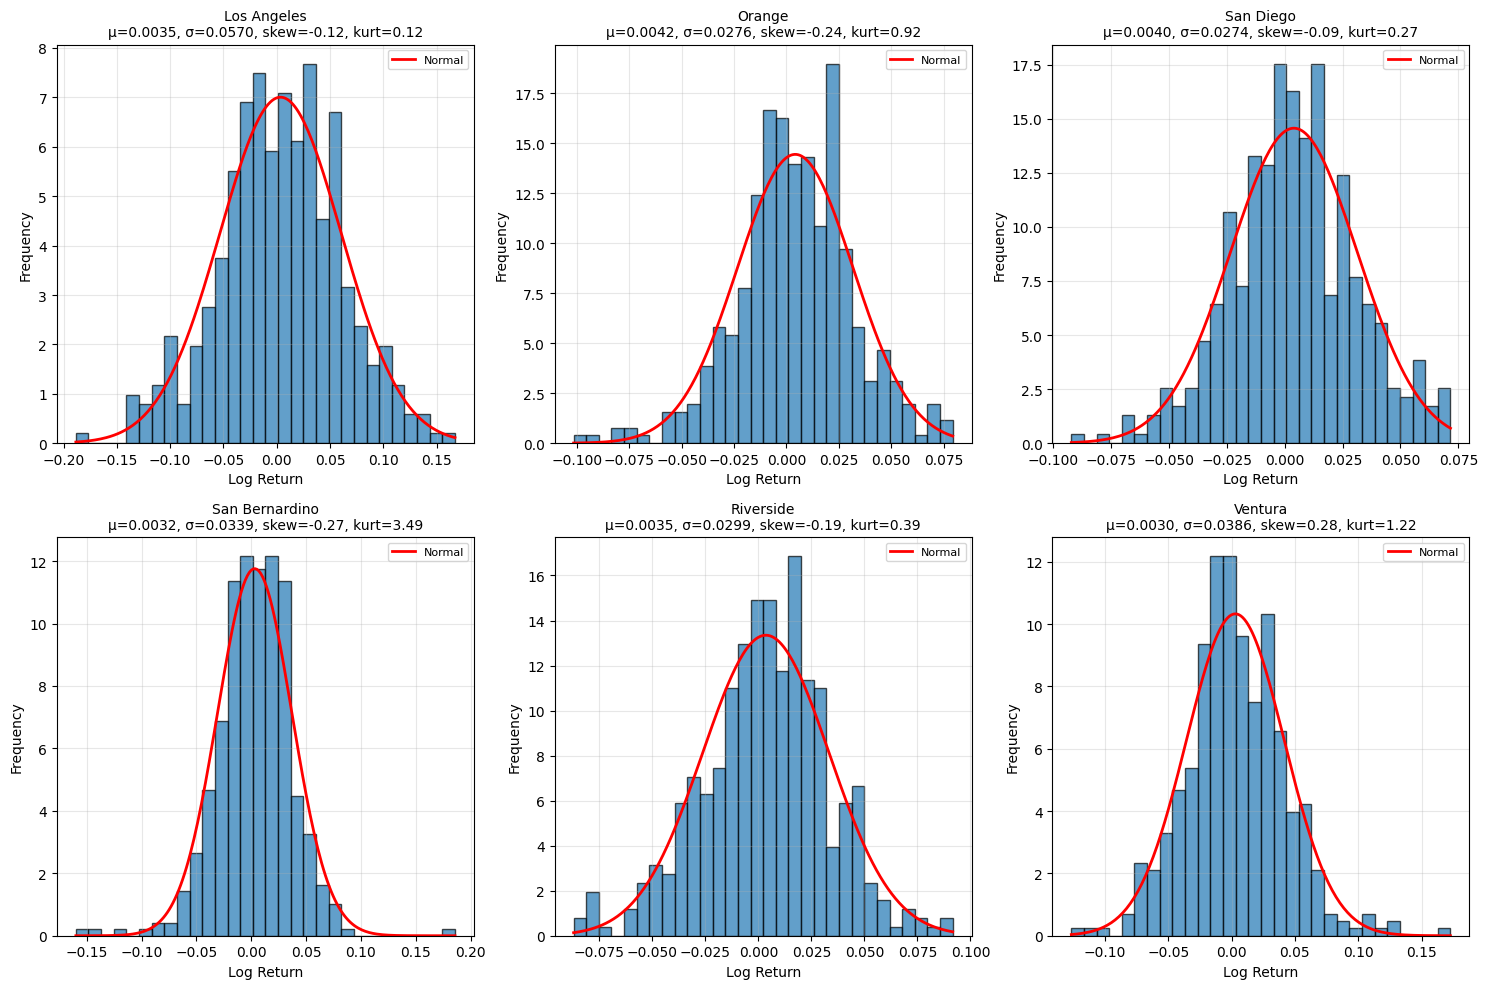

In [11]:
# Compare all SoCal regions side-by-side

# Create grid of subplots
n_regions = len(available)
n_cols = 3
n_rows = (n_regions + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()  # Flatten to 1D array for easy iteration

for i, region in enumerate(available):
    returns = compute_returns(df_regions, region, method="log")
    
    mean = returns.mean()
    std = returns.std()
    skew = returns.skew()
    kurt = returns.kurtosis()
    
    # Plot histogram with normal overlay
    ax = axes[i]
    ax.hist(returns, bins=30, density=True, alpha=0.7, edgecolor='black')
    
    x = np.linspace(returns.min(), returns.max(), 200)
    pdf = stats.norm.pdf(x, mean, std)
    ax.plot(x, pdf, 'r-', linewidth=2, label='Normal')
    
    ax.set_title(f"{region}\nμ={mean:.4f}, σ={std:.4f}, skew={skew:.2f}, kurt={kurt:.2f}", 
                 fontsize=10)
    ax.set_xlabel("Log Return")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Hide unused subplots
for i in range(n_regions, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# analysis for distributions shown
Across all Southern California regions, monthly log returns are centered close to zero, indicating that most month-to-month price changes are small. However, the width and shape of the distributions differ, revealing variations in volatility. San Diego, Orange, and Riverside show narrower distributions clustered around zero, suggesting these markets experience smaller, more consistent month-to-month price changes with fewer extreme swings. Los Angeles and Ventura exhibit wider distributions, indicating greater price volatility and less predictable month-to-month changes. San Bernardino stands out with the highest excess kurtosis (3.49), meaning its distribution has fatter tail hence, this region experiences more extreme monthly price swings compared to others. Skewness values across regions are generally small (positive or negative), showing no strong directional bias, but the deviations from the normal curve in the tails emphasize that SoCal housing returns are not perfectly normal and tend to exhibit mild to moderate fat-tailed behavior.

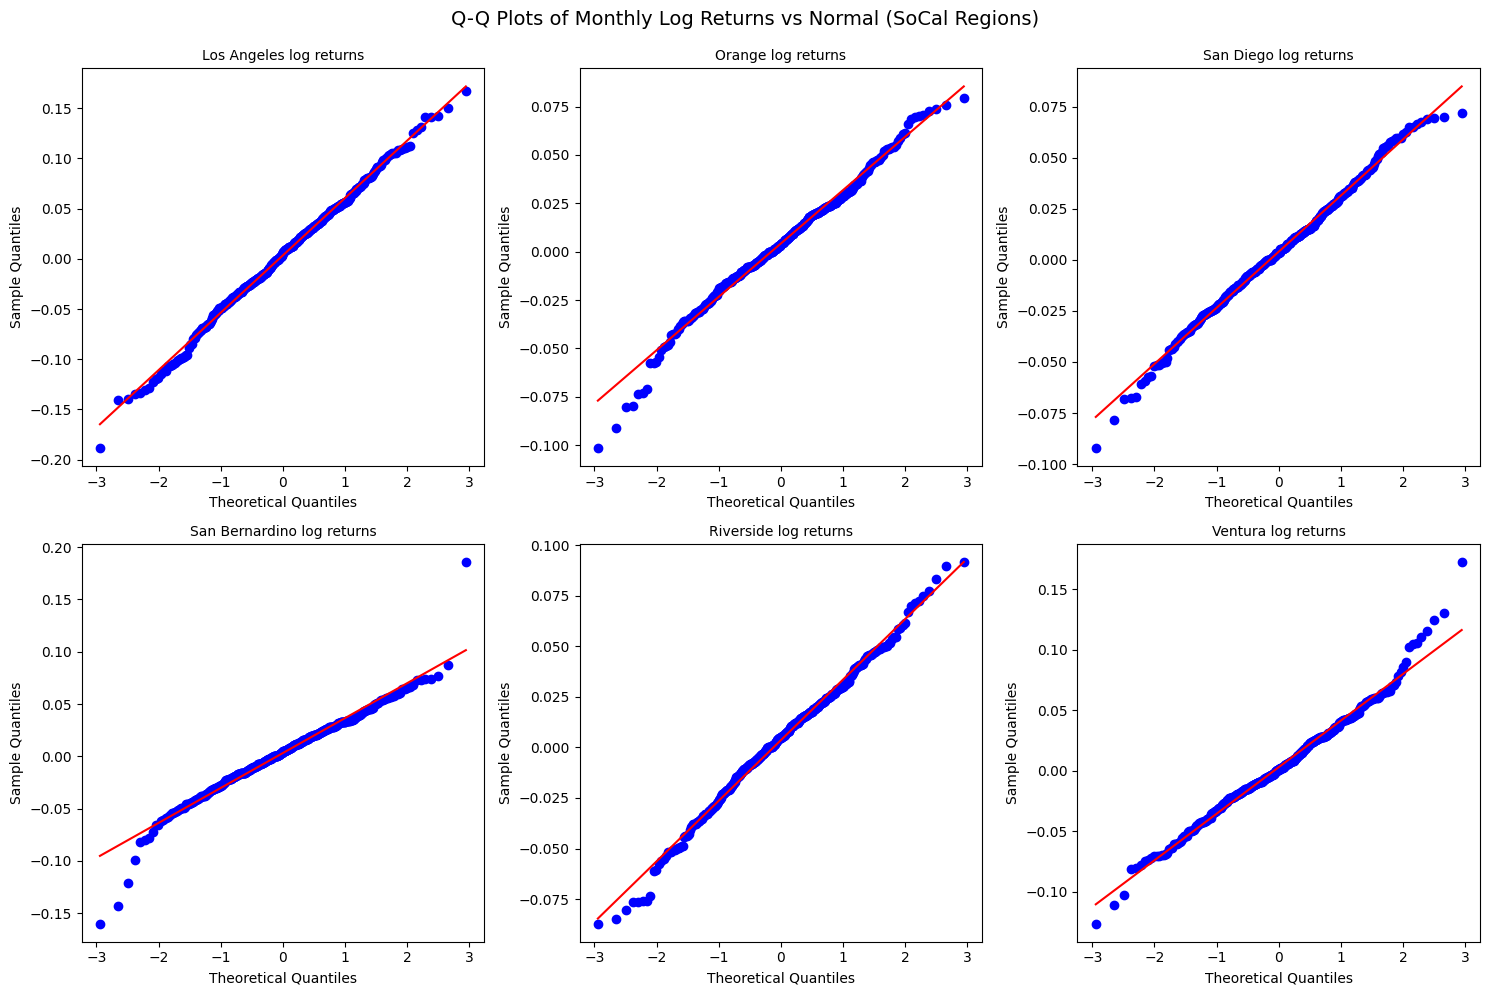

In [12]:
# Q-Q plots for SoCal regions vs Normal distribution

# Choose regions with enough data
socal_for_qq = available

n_regions = len(socal_for_qq)
n_cols = 3
n_rows = (n_regions + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, region in enumerate(socal_for_qq):
    ax = axes[i]
    returns = compute_returns(df_regions, region, method="log").dropna()
    
    stats.probplot(returns, dist="norm", plot=ax)
    ax.set_title(f"{region} log returns", fontsize=10)
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")

# Hide any unused axes
for j in range(n_regions, len(axes)):
    axes[j].axis("off")

plt.suptitle("Q-Q Plots of Monthly Log Returns vs Normal (SoCal Regions)", y=0.99, fontsize=14)
plt.tight_layout()
plt.show()


# Analysis
Similar to the distribution graphs above, this provides another perspective I thought was pretty cool to show. Although not much more info can be said that the distribution graphs above already showed. I can definitely see how the 2008 housing market crash and how it impacted each region.

## SoCal regions

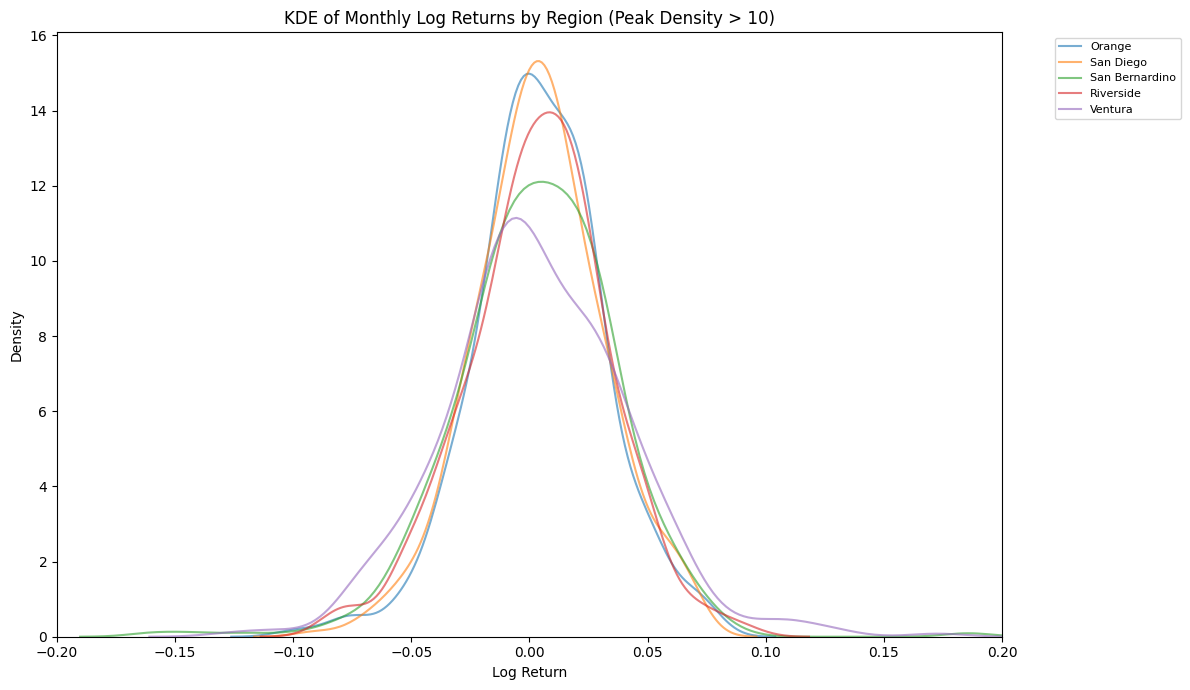

In [13]:
# KDE comparison across Socal regions (filtered by peak density > 10)

plt.figure(figsize=(12,7))

for col in regions:
    # Skip columns with insufficient data
    if df_regions[col].notna().sum() < 50:
        continue
    ret = compute_returns(df_regions, col, method="log")
    
    # Compute KDE to check peak density
    kde = stats.gaussian_kde(ret.dropna())
    x_eval = np.linspace(ret.min(), ret.max(), 200)
    density = kde(x_eval)
    
    # Only plot if max density > 10
    if density.max() > 10:
        sns.kdeplot(ret, label=col, alpha=0.6)

plt.title("KDE of Monthly Log Returns by Region (Peak Density > 10)")
plt.xlabel("Log Return")
plt.xlim(-0.2, 0.2)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# Analysis for KDE graph
The Kernel Density Estimation (KDE) plot provides a smoothed comparison of monthly log-return distributions across Southern California housing markets. All regions show bell-shaped curves centered near zero, confirming that small month-to-month price changes are the most common outcome. However, peak heights and distribution widths vary across counties, revealing differences in volatility and tail behavior. San Bernardino exhibits the tallest peak in the KDE, indicating a strong concentration of returns close to zero, but its curve also shows noticeably extended tails, reflecting the region’s high excess kurtosis and greater likelihood of extreme price movements. Orange and Riverside follow closely behind with relatively tall, narrow peaks, indicating low volatility and highly predictable return behavior. San Diego also displays a moderately narrow distribution, though its peak is slightly lower and its curve marginally wider, suggesting slightly more variability than Orange and Riverside. Ventura, by contrast, has the lowest peak and broadest overall distribution, pointing to higher volatility and more dispersed monthly price movements. Across all regions, the curves remain roughly symmetric around zero, showing no major directional bias in returns. Still, the differences in tail thickness, particularly in San Bernardino and Ventura highlight that some markets carry meaningfully higher tail risk.